# METR-LA Traffic Network with KoopmanGraph

This notebook applies **KoopmanGraph** to the **METR-LA** benchmark — a standard
traffic forecasting dataset from Los Angeles County loop detectors. We use the
real DCRNN road-network graph and **one weekday** of measured traffic speeds
(288 five-minute snapshots from a high-contrast congestion day), then train a
topology-aware Koopman model to forecast future speeds.

The evaluation protocol mirrors common traffic-forecasting practice: a
**chronological** train / validation / test split, multi-horizon MAE/RMSE on the
held-out future window, and an explicit comparison against **vectorized** DMD /
EDMD baselines that ignore road topology. We also report a persistence reference
so short-horizon skill is not overstated.

## Domain context (for non-experts)

A highway sensor network is a graph:

- **Sensors (nodes)** are loop detectors embedded in pavement that measure
  traffic speed every five minutes.
- **Road segments (edges)** connect nearby sensors when vehicles can flow
  between them on the freeway network.

Each node carries one feature in this tutorial:

| Feature | Meaning |
|---------|---------|
| **Speed** | Average traffic speed (mph), z-score normalized over the cached window |

Congestion at one sensor propagates to neighbors over time — a classic
**spatiotemporal graph dynamics** problem. KoopmanGraph respects that topology
during encoding and decoding, unlike methods that flatten all sensors into one
long vector.


## The encode → Koopman step → decode workflow

1. **Encode:** A GCN lifts per-sensor speed into a latent space while
   respecting the road-network adjacency and **Gaussian edge weights**.
2. **Koopman step:** A learned finite-dimensional operator advances latent
   states linearly: $z_{t+1} \approx z_t K^\top$.
3. **Decode:** A GCN maps advanced latent states back to physical speeds.

Training aligns one-step predictions with observed snapshots and adds an
autoregressive rollout term that matches `predict`. Optional forward-consistency
and eigenvalue hinge terms encourage stable linear evolution in latent space.


In [1]:
import warnings

from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import os
import random

import matplotlib

# Use a non-interactive backend when no display is available.
if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch_geometric.data import Data

try:
    from IPython import get_ipython

    if get_ipython() is not None and not os.environ.get("PYTEST_CURRENT_TEST"):
        get_ipython().run_line_magic("matplotlib", "inline")
except (ImportError, NameError):
    pass

from koopman_graph import (
    GNNDecoder,
    GNNEncoder,
    GraphKoopmanModel,
    GraphSnapshotSequence,
)
from koopman_graph.baselines import (
    DMDBaseline,
    EDMDBaseline,
)
from koopman_graph.data import temporal_split
from koopman_graph.datasets import MetrLaTrafficBenchmark
from koopman_graph.training import constant_loss_weights, linear_ramp_loss_weights

SEED = 3
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.grid": True,
        "grid.alpha": 0.3,
    }
)


## Load METR-LA data

Speed readings and graph metadata come from the
[DCRNN METR-LA release](https://github.com/liyaguang/DCRNN). KoopmanGraph ships
a tutorial cache under `data/metr_la/traffic.pt`: **288** consecutive 5-minute
samples (one weekday) starting at HDF5 row offset **6048**, chosen for clear
rush-hour contrast. Rebuild or enlarge the cache with
`scripts/download_metr_la.py` (see its acquisition notes).

For a quick run, the loaded sequence is truncated; interactive demos can use a longer window.


In [2]:
topology = MetrLaTrafficBenchmark.load_topology()
data_sequence = MetrLaTrafficBenchmark.load_sequence()
if os.environ.get("PYTEST_CURRENT_TEST"):
    data_sequence = GraphSnapshotSequence(data_sequence.snapshots[:25])
elif data_sequence.num_timesteps < 100:
    raise RuntimeError(
        "Expected the weekday METR-LA tutorial cache (>= 100 snapshots), "
        f"got {data_sequence.num_timesteps}. Rebuild with:\n"
        "  python scripts/download_metr_la.py "
        "--h5-path data/metr_la/metr-la.h5 --force"
    )

split = temporal_split(data_sequence)

print(f"Sensors: {topology['num_nodes']}")
print(f"Road edges (directed): {topology['edge_index'].shape[1]}")
print(f"Snapshots: {data_sequence.num_timesteps}")
print(
    f"Train / val / test: "
    f"{split.train.num_timesteps} / {split.val.num_timesteps} / {split.test.num_timesteps}"
)
print(f"Feature dim: {data_sequence.in_channels}")
print(f"First snapshot shape: {data_sequence[0].x.shape}")


Sensors: 207
Road edges (directed): 2833
Snapshots: 288
Train / val / test: 201 / 28 / 59
Feature dim: 1
First snapshot shape: torch.Size([207, 1])


Plot normalized speed at a few sensors over the cached weekday window.


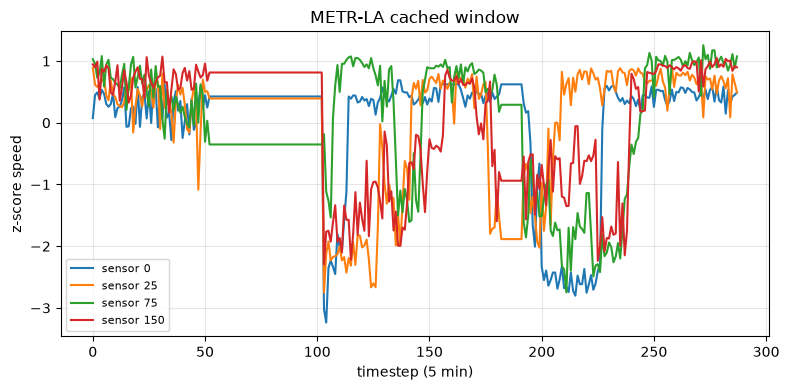

In [3]:
sensor_ids = [0, 25, 75, 150]
times = torch.arange(data_sequence.num_timesteps)

fig, ax = plt.subplots(figsize=(8, 4))
for sensor_id in sensor_ids:
    values = torch.stack([snap.x[sensor_id, 0] for snap in data_sequence])
    ax.plot(times.numpy(), values.numpy(), label=f"sensor {sensor_id}")
ax.set_xlabel("timestep (5 min)")
ax.set_ylabel("z-score speed")
ax.set_title("METR-LA cached window")
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()


## Build the graph Koopman model

We use a GCN encoder/decoder sized for one speed feature on 207 sensors, with an
**ODO** Koopman parameterization (soft spectral bound) so multi-step rollouts stay
numerically well-behaved while still allowing non-trivial congestion dynamics.


In [4]:
in_channels = data_sequence.in_channels
hidden_channels = 64
latent_dim = 64

torch.manual_seed(SEED)
encoder = GNNEncoder(in_channels, hidden_channels, latent_dim)
decoder = GNNDecoder(latent_dim, hidden_channels, in_channels)
model = GraphKoopmanModel(
    encoder=encoder,
    decoder=decoder,
    latent_dim=latent_dim,
    time_step=1.0,
    koopman_parameterization="odo",
    koopman_max_spectral_radius=1.05,
)
print(model)


GraphKoopmanModel(
  (encoder): GNNEncoder(
    (activation): ReLU()
    (convs): ModuleList(
      (0): GCNConv(1, 64)
      (1): GCNConv(64, 64)
    )
  )
  (decoder): GNNDecoder(
    (activation): ReLU()
    (convs): ModuleList(
      (0): GCNConv(64, 64)
      (1): GCNConv(64, 1)
    )
  )
  (koopman): KoopmanOperator()
)


## Gaussian edge weights on the road network

The cached METR-LA loader keeps the **Gaussian-kernel weighted adjacency** from
DCRNN: each directed road segment carries a scalar `edge_weight` aligned with
`edge_index`. GCN layers consume those weights during encode/decode.


In [5]:
edge_weight = data_sequence.edge_weight
assert edge_weight is not None, "METR-LA sequence should retain Gaussian edge weights"

print(f"edge_weight shape: {tuple(edge_weight.shape)}")
print(
    f"edge_weight range: [{float(edge_weight.min()):.4f}, {float(edge_weight.max()):.4f}]"
)

snap = data_sequence[0]
z_weighted = model.encode(snap)
snap_unweighted = Data(x=snap.x, edge_index=snap.edge_index)
z_unweighted = model.encode(snap_unweighted)
latent_mse = torch.mean((z_weighted - z_unweighted) ** 2).item()
print(f"Mean latent MSE (weighted vs unweighted encode): {latent_mse:.6f}")


edge_weight shape: (2833,)
edge_weight range: [0.1001, 1.0000]
Mean latent MSE (weighted vs unweighted encode): 0.000082


## Train the graph model

We train on the earliest 70% of snapshots, validate on the next 10%, and hold
out the final 20% for test evaluation. Loss weights **ramp** from one-step
emphasis into multi-step rollout so the model first learns local congestion
transitions, then open-loop forecast skill.

`restore_best_weights=True` reloads the **best validation** checkpoint; the next
cell prints that epoch index and the restored weights are used for evaluation.
Model initialization and training use a fixed `SEED` so Restart & Run All is
reproducible on CPU.


In [6]:
requested_horizons = (1, 2, 3) if os.environ.get("PYTEST_CURRENT_TEST") else (3, 6, 12)
max_eval_horizon = split.test.num_timesteps - 1
eval_horizons = tuple(h for h in requested_horizons if h <= max_eval_horizon)
if not eval_horizons:
    raise ValueError(
        f"test split has {split.test.num_timesteps} timesteps; "
        f"need at least {min(requested_horizons) + 1} for evaluation"
    )
predict_steps = max(eval_horizons)
rollout_horizon = min(
    predict_steps,
    min(split.train.num_timesteps, split.val.num_timesteps) - 1,
)
EPOCHS = 20 if os.environ.get("PYTEST_CURRENT_TEST") else 120
RAMP_EPOCHS = 5 if os.environ.get("PYTEST_CURRENT_TEST") else 40

loss_schedule = linear_ramp_loss_weights(
    constant_loss_weights(
        reconstruction=1.0, forward=1.0, rollout=0.25, eigenvalue=0.05
    ),
    constant_loss_weights(
        reconstruction=1.0, forward=0.5, rollout=2.0, eigenvalue=0.05
    ),
    ramp_epochs=RAMP_EPOCHS,
)

torch.manual_seed(SEED)
history = model.fit(
    split.train,
    validation_sequence=split.val,
    epochs=EPOCHS,
    lr=1.5e-3,
    loss_weight_schedule=loss_schedule,
    rollout_horizon=rollout_horizon,
    max_grad_norm=1.0,
    early_stopping_patience=30,
    restore_best_weights=True,
)

print(f"Initial train loss: {history.loss[0]:.6f}")
print(f"Final train loss: {history.loss[-1]:.6f}")
print(
    "Initial train breakdown: "
    f"recon={history.reconstruction_loss[0]:.4f}, "
    f"forward={history.forward_loss[0]:.4f}, "
    f"rollout={history.rollout_loss[0]:.4f}"
)
print(
    "Final train breakdown: "
    f"recon={history.reconstruction_loss[-1]:.4f}, "
    f"forward={history.forward_loss[-1]:.4f}, "
    f"rollout={history.rollout_loss[-1]:.4f}"
)
if history.val_loss is not None:
    print(f"Initial val loss: {history.val_loss[0]:.6f}")
    print(f"Final val loss: {history.val_loss[-1]:.6f}")
    best_val_epoch = history.val_loss.index(min(history.val_loss))
    print(
        f"Best validation epoch: {best_val_epoch} "
        f"(loss={history.val_loss[best_val_epoch]:.6f}); "
        "these weights are restored for evaluation"
    )


Initial train loss: 0.989681
Final train loss: 1.115851
Initial train breakdown: recon=0.8148, forward=0.0007, rollout=0.6967
Final train breakdown: recon=0.5553, forward=0.0028, rollout=0.3071
Initial val loss: 2.323636
Final val loss: 3.665966
Best validation epoch: 5 (loss=2.025023); these weights are restored for evaluation


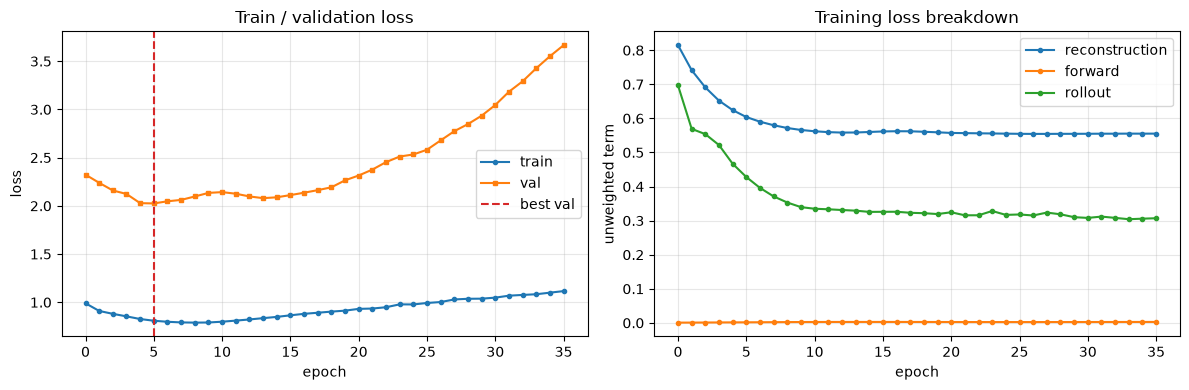

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.loss, marker="o", markersize=3, label="train")
if history.val_loss is not None:
    axes[0].plot(history.val_loss, marker="s", markersize=3, label="val")
    best_val_epoch = history.val_loss.index(min(history.val_loss))
    axes[0].axvline(best_val_epoch, color="C3", linestyle="--", label="best val")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[0].set_title("Train / validation loss")
axes[0].legend()

axes[1].plot(history.reconstruction_loss, marker="o", markersize=3, label="reconstruction")
axes[1].plot(history.forward_loss, marker="o", markersize=3, label="forward")
axes[1].plot(history.rollout_loss, marker="o", markersize=3, label="rollout")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("unweighted term")
axes[1].set_title("Training loss breakdown")
axes[1].legend()
plt.tight_layout()
plt.show()


## Evaluate on the held-out test split

`evaluate` reports MAE, RMSE, and MAPE at standard forecast horizons (3/6/12
when the test split is long enough), averaged over **all valid forecast origins**
in the test window. That multi-origin protocol is the primary accuracy claim for
the graph model.

> **Interpret MAPE with care here.** Speeds are z-score normalized, so target
> values cross zero and percentage errors blow up near it. On this cache the
> MAPE column is inflated and unstable; prefer MAE/RMSE, or compute MAPE on
> denormalized speeds (mph) when comparing against published METR-LA results.


In [8]:
result = model.evaluate(split.test, horizons=eval_horizons)
for metric in result.horizons:
    print(
        f"horizon {metric.horizon:>2}: "
        f"MAE={metric.mae:.4f}, RMSE={metric.rmse:.4f}, MAPE={metric.mape:.4f}"
    )
print(
    "Aggregate over horizons: "
    f"MAE={result.aggregate_mae:.4f}, "
    f"RMSE={result.aggregate_rmse:.4f}, "
    f"MAPE={result.aggregate_mape:.4f}"
)

graph_preds = model.predict(split.test[0], steps=predict_steps)
graph_truth = [split.test[t] for t in range(1, predict_steps + 1)]
graph_mse = torch.mean(
    torch.stack(
        [
            torch.mean((pred.x - truth.x) ** 2)
            for pred, truth in zip(graph_preds, graph_truth, strict=True)
        ]
    )
)
print(f"Single-origin rollout MSE (for plotting): {graph_mse.item():.6f}")

pred_stack = torch.stack([pred.x for pred in graph_preds])
truth_stack = torch.stack([truth.x for truth in graph_truth])
print(
    "Single-origin temporal std (mean over sensors): "
    f"pred={float(pred_stack.std(0).mean()):.4f}, "
    f"truth={float(truth_stack.std(0).mean()):.4f}"
)
network_pred = pred_stack.mean((1, 2))
network_truth = truth_stack.mean((1, 2))
if predict_steps >= 2:
    network_corr = float(
        torch.corrcoef(torch.stack([network_pred, network_truth]))[0, 1]
    )
    print(f"Single-origin network-mean speed correlation: {network_corr:.4f}")


horizon  3: MAE=0.4914, RMSE=0.6500, MAPE=1.6955
horizon  6: MAE=0.4946, RMSE=0.6660, MAPE=1.4963
horizon 12: MAE=0.6532, RMSE=0.7809, MAPE=1.0232
Aggregate over horizons: MAE=0.5464, RMSE=0.6990, MAPE=1.4050
Single-origin rollout MSE (for plotting): 0.883709
Single-origin temporal std (mean over sensors): pred=0.2287, truth=0.4187
Single-origin network-mean speed correlation: 0.8740


## DMD and EDMD baselines

Classical Koopman pipelines ignore graph structure: all sensor speeds are
concatenated into one vector $v_t \in \mathbb{R}^{N}$ and fit with Dynamic Mode
Decomposition (DMD), $v_{t+1} \approx v_t K^\top$.

The packaged **`DMDBaseline`** solves this linear map directly by least
squares. **`EDMDBaseline`** extends DMD with lifted dictionaries in the
flattened state space (Williams et al., 2015, and kernel-EDMD variants):

- ``dictionary="polynomial"`` — identity or identity-plus-squares (default here)
- ``dictionary="rbf"`` — explicit Gaussian RBF centers (``num_centers``,
  ``length_scale``); included in the table below
- ``dictionary="kernel"`` — kernel sections against training centers
  (Gaussian / polynomial) or linear-kernel ≡ DMD. Full-data centers are
  $O(T^2)$ in feature dimension — fine for tiny synthetic checks, but **not**
  run on this METR-LA weekday cache (use a subsampled ``num_centers`` if you
  experiment locally)

Neither baseline uses gradient training. We compare them to the graph model on
the **same multi-origin RMSE protocol** as `evaluate`, and also report a
**persistence** (repeat last observation) reference. Persistence is often strong
at very short traffic horizons. The claim for this tutorial is that a trained
topology-aware model beats vectorized DMD/EDMD with stable forecasts on this
cache — not that every sensor trajectory is reconstructed faithfully, and not
that this is a METR-LA leaderboard entry.


In [9]:
baseline = DMDBaseline(time_step=1.0).fit(split.train)
edmd_baseline = EDMDBaseline(
    time_step=1.0, dictionary="polynomial", polynomial_degree=2
).fit(split.train)
# RBF dictionary: fixed center count keeps the classical peer cheap on METR-LA.
edmd_rbf = EDMDBaseline(
    time_step=1.0,
    dictionary="rbf",
    num_centers=32,
    length_scale=10.0,
).fit(split.train)
# Full kernel EDMD (one center per train snapshot) is O(T^2); skip on this cache.
print(
    "Skipping dictionary='kernel' on METR-LA train "
    f"(T={split.train.num_timesteps}); use a small synthetic sequence or "
    "subsampled num_centers for local kernel experiments."
)


def multi_origin_rmse(predict_fn, test_seq, horizons: tuple[int, ...]) -> dict[int, float]:
    """RMSE averaged over all valid origins and steps within each horizon."""
    scores: dict[int, float] = {}
    for horizon in horizons:
        sq_errors: list[torch.Tensor] = []
        for origin in range(0, test_seq.num_timesteps - horizon):
            preds = predict_fn(test_seq[origin], horizon)
            for step in range(horizon):
                sq_errors.append((preds[step].x - test_seq[origin + 1 + step].x).pow(2))
        scores[horizon] = float(torch.stack(sq_errors).mean().sqrt())
    return scores


def persistence_predict(snapshot: Data, steps: int) -> list[Data]:
    ew = getattr(snapshot, "edge_weight", None)
    return [
        Data(x=snapshot.x.clone(), edge_index=snapshot.edge_index, edge_weight=ew)
        for _ in range(steps)
    ]


graph_rmses = {m.horizon: m.rmse for m in result.horizons}
dmd_rmses = multi_origin_rmse(lambda s, h: baseline.predict(s, steps=h), split.test, eval_horizons)
edmd_rmses = multi_origin_rmse(
    lambda s, h: edmd_baseline.predict(s, steps=h), split.test, eval_horizons
)
edmd_rbf_rmses = multi_origin_rmse(
    lambda s, h: edmd_rbf.predict(s, steps=h), split.test, eval_horizons
)
persist_rmses = multi_origin_rmse(persistence_predict, split.test, eval_horizons)

print("Multi-origin test RMSE by horizon")
print(
    f"{'horizon':>8} {'graph':>10} {'DMD':>10} {'EDMD':>10} "
    f"{'EDMD-RBF':>10} {'persist':>10}"
)
for horizon in eval_horizons:
    print(
        f"{horizon:>8} "
        f"{graph_rmses[horizon]:>10.4f} "
        f"{dmd_rmses[horizon]:>10.4f} "
        f"{edmd_rmses[horizon]:>10.4f} "
        f"{edmd_rbf_rmses[horizon]:>10.4f} "
        f"{persist_rmses[horizon]:>10.4f}"
    )

graph_agg = sum(graph_rmses[h] for h in eval_horizons) / len(eval_horizons)
dmd_agg = sum(dmd_rmses[h] for h in eval_horizons) / len(eval_horizons)
edmd_agg = sum(edmd_rmses[h] for h in eval_horizons) / len(eval_horizons)
edmd_rbf_agg = sum(edmd_rbf_rmses[h] for h in eval_horizons) / len(eval_horizons)
persist_agg = sum(persist_rmses[h] for h in eval_horizons) / len(eval_horizons)
print(
    f"{'mean':>8} "
    f"{graph_agg:>10.4f} "
    f"{dmd_agg:>10.4f} "
    f"{edmd_agg:>10.4f} "
    f"{edmd_rbf_agg:>10.4f} "
    f"{persist_agg:>10.4f}"
)

baseline_graphs = baseline.predict(split.test[0], steps=predict_steps)
edmd_graphs = edmd_baseline.predict(split.test[0], steps=predict_steps)
edmd_rbf_graphs = edmd_rbf.predict(split.test[0], steps=predict_steps)


def rollout_mse(preds: list[Data], truths: list) -> torch.Tensor:
    return torch.mean(
        torch.stack(
            [
                torch.mean((pred.x - truth.x) ** 2)
                for pred, truth in zip(preds, truths, strict=True)
            ]
        )
    )


baseline_mse = rollout_mse(baseline_graphs, graph_truth)
edmd_mse = rollout_mse(edmd_graphs, graph_truth)
edmd_rbf_mse = rollout_mse(edmd_rbf_graphs, graph_truth)
print()
print(f"Single-origin rollout MSE — DMD:  {baseline_mse.item():.6f}")
print(f"Single-origin rollout MSE — EDMD: {edmd_mse.item():.6f}")
print(f"Single-origin rollout MSE — EDMD-RBF: {edmd_rbf_mse.item():.6f}")
print(f"Single-origin rollout MSE — graph: {graph_mse.item():.6f}")

classical_best = min(dmd_agg, edmd_agg, edmd_rbf_agg)
if graph_agg < classical_best:
    print()
    print("Graph model beats DMD/EDMD on mean multi-origin RMSE.")
else:
    print()
    print("Vectorized baseline wins mean multi-origin RMSE on this cache.")
if graph_agg <= persist_agg:
    print("Graph model also matches or beats persistence on mean multi-origin RMSE.")
else:
    print(
        "Persistence remains competitive (common at short traffic horizons); "
        "prefer the DMD/EDMD comparison for the topology-aware claim."
    )


Multi-origin test RMSE by horizon
 horizon      graph        DMD       EDMD    persist
       3     0.6500     1.6233     1.2040     0.5977
       6     0.6660     1.6652     1.2155     0.6640
      12     0.7809     1.7085     1.2616     0.7788
    mean     0.6990     1.6657     1.2270     0.6801

Single-origin rollout MSE — DMD:  7.611919
Single-origin rollout MSE — EDMD: 4.011895
Single-origin rollout MSE — graph: 0.883709

Graph model beats DMD/EDMD on mean multi-origin RMSE.
Persistence remains competitive (common at short traffic horizons); prefer the DMD/EDMD comparison for the topology-aware claim.


## Visualize representative rollouts

Figures use a **single test origin** for readability; multi-origin RMSE above is
the primary accuracy claim.

- **Network-mean:** graph vs truth congestion level over the horizon (some
  open-loop drift at longer steps is expected).
- **Higher-variance sensor:** a detector with large truth variability where the
  graph forecast also has non-trivial temporal std — typically smoother than
  truth, while DMD/EDMD may blow up.
- **Low-variance sensor:** graph stays comparatively stable; classical baselines
  often inject spurious volatility.


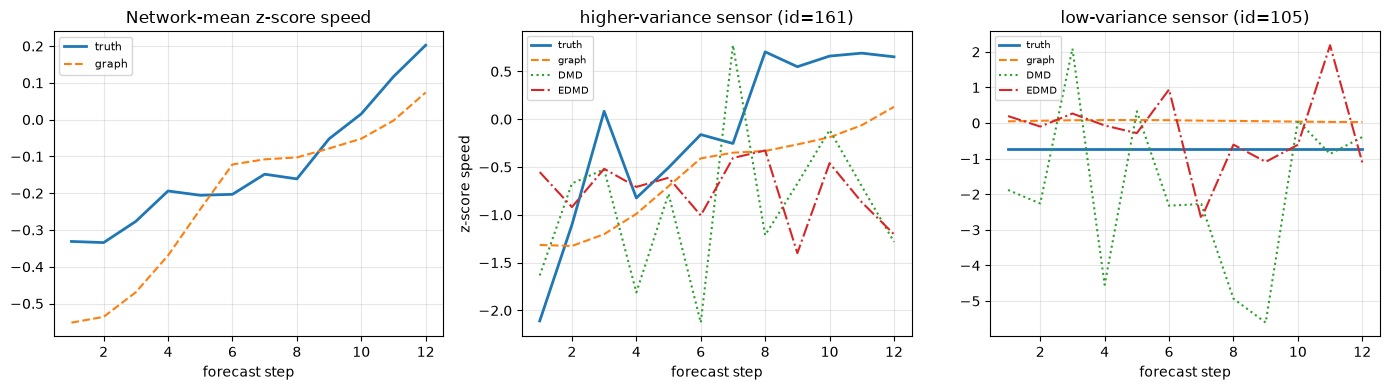

In [10]:
def rollout_series(
    preds: list[Data],
    truths: list,
    sensor_id: int,
) -> tuple[torch.Tensor, torch.Tensor]:
    pred_values = torch.stack([pred.x[sensor_id, 0] for pred in preds])
    truth_values = torch.stack([truth.x[sensor_id, 0] for truth in truths])
    return pred_values, truth_values


truth_var = truth_stack.std(0).squeeze()
pred_var = pred_stack.std(0).squeeze()
# Prefer sensors that are dynamic in both truth and the graph forecast.
dynamic_score = torch.minimum(truth_var, pred_var)
candidates = (truth_var >= truth_var.quantile(0.7)) & (pred_var >= pred_var.median())
if bool(candidates.any()):
    demo_sensor = int(torch.arange(truth_var.numel())[candidates][dynamic_score[candidates].argmax()])
else:
    demo_sensor = int(dynamic_score.argmax())
calm_sensor = int(truth_var.argmin())
pred_times = torch.arange(1, predict_steps + 1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(pred_times.numpy(), network_truth.numpy(), label="truth", linewidth=2)
axes[0].plot(pred_times.numpy(), network_pred.numpy(), label="graph", linestyle="--")
axes[0].set_title("Network-mean z-score speed")
axes[0].set_xlabel("forecast step")
axes[0].legend(fontsize=8)

for ax, sensor_id, title in zip(
    axes[1:],
    (demo_sensor, calm_sensor),
    ("higher-variance sensor", "low-variance sensor"),
    strict=True,
):
    g_pred, g_truth = rollout_series(graph_preds, graph_truth, sensor_id)
    d_pred, _ = rollout_series(baseline_graphs, graph_truth, sensor_id)
    e_pred, _ = rollout_series(edmd_graphs, graph_truth, sensor_id)
    ax.plot(pred_times.numpy(), g_truth.numpy(), label="truth", linewidth=2)
    ax.plot(pred_times.numpy(), g_pred.numpy(), label="graph", linestyle="--")
    ax.plot(pred_times.numpy(), d_pred.numpy(), label="DMD", linestyle=":")
    ax.plot(pred_times.numpy(), e_pred.numpy(), label="EDMD", linestyle="-.")
    ax.set_title(f"{title} (id={sensor_id})")
    ax.set_xlabel("forecast step")
    ax.legend(fontsize=7)

axes[1].set_ylabel("z-score speed")
plt.tight_layout()
plt.show()


## Windowed mini-batch throughput

Long trajectories can use fixed-length temporal windows so each optimizer step
processes a shorter temporal slice instead of the full sequence. On this train
split we time full-sequence vs windowed updates (fewer timed runs in the quick-demo profile).


Throughput benchmark: window_length=12, 190 valid windows, median of 3 timed run(s) after 1 warmup(s)
configuration                 upd/epoch    epoch s   s/update      upd/s
full sequence                         1      3.171      3.171       0.32
windowed bs=1, 31 windows            31      4.954      0.160       6.26
windowed bs=4, 8 windows              2      1.134      0.567       1.76


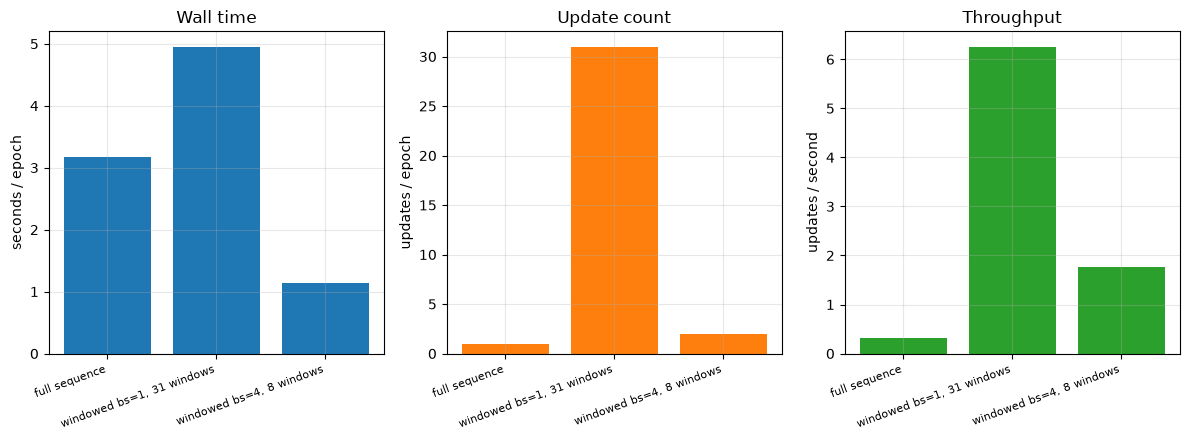

In [11]:
import statistics
import time


def build_throughput_probe() -> GraphKoopmanModel:
    """Return a fresh untrained model for timing (avoids deepcopy overhead)."""
    torch.manual_seed(SEED)
    enc = GNNEncoder(in_channels, hidden_channels, latent_dim)
    dec = GNNDecoder(latent_dim, hidden_channels, in_channels)
    return GraphKoopmanModel(
        encoder=enc,
        decoder=dec,
        latent_dim=latent_dim,
        time_step=1.0,
        koopman_parameterization="odo",
        koopman_max_spectral_radius=1.05,
    )


window_length = 12
n_valid_windows = max(split.train.num_timesteps - window_length + 1, 1)
timed_runs = 1 if os.environ.get("PYTEST_CURRENT_TEST") else 3
warmups = 0 if os.environ.get("PYTEST_CURRENT_TEST") else 1
probe_epochs = 1
probe_weights = constant_loss_weights(reconstruction=1.0, forward=0.5, rollout=0.5)


def time_fit(**fit_kwargs) -> float:
    probe = build_throughput_probe()
    start = time.perf_counter()
    probe.fit(
        split.train,
        epochs=probe_epochs,
        lr=1e-3,
        loss_weights=probe_weights,
        **fit_kwargs,
    )
    return time.perf_counter() - start


configs = [
    ("full sequence", {}),
    (
        f"windowed bs=1, {min(n_valid_windows, 31)} windows",
        {
            "window_length": window_length,
            "batch_size": 1,
            "windows_per_epoch": min(n_valid_windows, 31),
        },
    ),
    (
        "windowed bs=4, 8 windows",
        {"window_length": window_length, "batch_size": 4, "windows_per_epoch": 8},
    ),
]

print(
    f"Throughput benchmark: window_length={window_length}, "
    f"{n_valid_windows} valid windows, median of {timed_runs} timed run(s) "
    f"after {warmups} warmup(s)"
)
print(
    f"{'configuration':<28} {'upd/epoch':>10} {'epoch s':>10} "
    f"{'s/update':>10} {'upd/s':>10}"
)

labels: list[str] = []
seconds: list[float] = []
updates: list[float] = []
for label, kwargs in configs:
    for _ in range(warmups):
        time_fit(**kwargs)
    samples = [time_fit(**kwargs) for _ in range(timed_runs)]
    elapsed = statistics.median(samples)
    if "windows_per_epoch" in kwargs:
        n_updates = kwargs["windows_per_epoch"] / kwargs.get("batch_size", 1)
    else:
        n_updates = 1.0
    labels.append(label)
    seconds.append(elapsed)
    updates.append(n_updates)
    print(
        f"{label:<28} {n_updates:>10.0f} {elapsed:>10.3f} "
        f"{elapsed / n_updates:>10.3f} {n_updates / elapsed:>10.2f}"
    )

fig, axes = plt.subplots(1, 3, figsize=(12, 4.5))
axes[0].bar(range(len(labels)), seconds, color="C0")
axes[0].set_xticks(range(len(labels)))
axes[0].set_xticklabels(labels, rotation=20, ha="right", fontsize=8)
axes[0].set_ylabel("seconds / epoch")
axes[0].set_title("Wall time")

axes[1].bar(range(len(labels)), updates, color="C1")
axes[1].set_xticks(range(len(labels)))
axes[1].set_xticklabels(labels, rotation=20, ha="right", fontsize=8)
axes[1].set_ylabel("updates / epoch")
axes[1].set_title("Update count")

upd_per_s = [u / s for u, s in zip(updates, seconds, strict=True)]
axes[2].bar(range(len(labels)), upd_per_s, color="C2")
axes[2].set_xticks(range(len(labels)))
axes[2].set_xticklabels(labels, rotation=20, ha="right", fontsize=8)
axes[2].set_ylabel("updates / second")
axes[2].set_title("Throughput")
plt.tight_layout()
plt.show()


## Takeaways

- The shipped cache is a **full weekday** (288 steps) of METR-LA speeds on the
  DCRNN road graph with Gaussian edge weights.
- Training uses a **loss-weight ramp** and restores the **best validation**
  checkpoint for evaluation. A fixed `SEED` makes Restart & Run All reproducible
  on CPU.
- On multi-origin test RMSE, the topology-aware model beats **vectorized
  DMD/EDMD**. Persistence can remain competitive at short horizons.
- Aggregate forecasts are **non-flat**, but individual sensors are often
  **smoothed**: the graph model avoids DMD/EDMD blow-ups more than it tracks
  every volatile detector. Prefer MAE/RMSE over MAPE on z-score targets.

## Next steps

- See [`01_synthetic_graph.ipynb`](01_synthetic_graph.ipynb) for a smaller
  synthetic graph walkthrough.
- See [`02_ieee118_bus.ipynb`](02_ieee118_bus.ipynb) for a smart-grid example
  on the IEEE 118-bus network.
- Explore the [API reference](https://koopmangraph.readthedocs.io/en/latest/api.html)
  for loss schedules, early stopping, and GAT encoders.
